# Analysis: Peak detection + alignment + CSV + plots


In [9]:
# Cell 1: imports + paths + params
from pathlib import Path
import yaml
import numpy as np
import torch
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

from infer_beat import (
    build_model,
    apply_position_mode,
    normalize_feats,
    build_beat_windows,
    slice_by_beats,
)

# paths (assume cwd = MERIX SUBMISSION/MIREX_Model)
cfg_path = Path("config_beat_mazurka_level6.yaml")
ckpt_path = Path("check/beat_mazurka/level_6/beat_mazurka_L6_20260130_141117/best.pt")
input_dir = Path("beat_data_mazurka_performer_levels")
pattern = "M06-3_*_L6.npz"

# pred peak params (lower if too few peaks)
pred_height = 0.05
pred_min_dist = 6
pred_prominence = 0.03

# true peak params
use_true_binary = True  # True if boundary_probs are 0/1
true_height = 0.05
true_min_dist = 6
true_prominence = 0.03

# assignment radius (beats)
assign_radius = 6

# output


In [10]:
# Cell 2: main analysis function (with output_head switch)
def analyze_boundary_dist(
    config_path,
    ckpt_path,
    input_dir,
    pattern,
    output_head="dist",
    pred_height=0.05,
    pred_min_dist=6,
    pred_prominence=0.03,
    use_true_binary=True,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
):
    cfg = yaml.safe_load(Path(config_path).read_text())
    files = sorted(Path(input_dir).glob(pattern))
    performer_cond = cfg.get("model", {}).get("performer_cond", False)
    perf_map = {}
    if performer_cond:
        import re
        perf_re = cfg.get("data", {}).get("performer_id_regex", r"(pid[^_]+)")
        pattern_re = re.compile(perf_re)
        tokens = []
        for f in files:
            m = pattern_re.search(f.stem)
            if m:
                tokens.append(m.group(1))
        tokens = sorted(set(tokens))
        perf_map = {t: i + 1 for i, t in enumerate(tokens)}
        cfg.setdefault("model", {})["performer_vocab_size"] = len(perf_map) + 1
    if not files:
        raise RuntimeError("No matching npz files")

    sample = np.load(files[0])
    input_dim = sample["note_feats"].shape[1]

    model = build_model(cfg, input_dim=input_dim)
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.eval()

    position_mode = cfg.get("data", {}).get("position_mode", "absolute")
    value_ranges = cfg.get("data", {}).get("value_ranges")
    window_beats = cfg.get("data", {}).get("beat_sequence_length")
    window_stride = cfg.get("data", {}).get("beat_stride")
    max_len = cfg.get("data", {}).get("max_len")
    include_empty_beats = cfg.get("model", {}).get("include_empty_beats", False)

    def infer_probs_for_npz(npz_path):
        performer_id = 0
        if perf_map:
            import re
            perf_re = cfg.get("data", {}).get("performer_id_regex", r"(pid[^_]+)")
            m = re.search(perf_re, Path(npz_path).stem)
            if m:
                performer_id = perf_map.get(m.group(1), 0)
        npz = np.load(npz_path)
        note_feats = npz["note_feats"]
        beat_ids = npz["beat_ids"]
        if beat_ids.size == 0:
            return np.array([])

        num_beats = int(beat_ids.max()) + 1

        if window_beats is None:
            feats = apply_position_mode(note_feats, position_mode)
            if value_ranges:
                feats = normalize_feats(feats, value_ranges)
            feats_t = torch.tensor(feats).unsqueeze(0)
            beat_ids_t = torch.tensor(beat_ids).unsqueeze(0)
            attn_mask = beat_ids_t >= 0
            with torch.no_grad():
                logits, _ = model(
                    feats_t,
                    beat_ids=beat_ids_t,
                    num_beats=num_beats,
                    attn_mask=attn_mask,
                    labels=None,
                    output_head=output_head,
                    performer_ids=torch.tensor([performer_id]),
                )
                probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            if not include_empty_beats:
                valid_beats = np.zeros(num_beats, dtype=bool)
                valid_beats[np.unique(beat_ids[beat_ids >= 0])] = True
                probs = np.where(valid_beats, probs, 0.0)
            return probs

        windows = build_beat_windows(num_beats, int(window_beats), int(window_stride))
        sum_probs = np.zeros(num_beats, dtype=np.float64)
        count_probs = np.zeros(num_beats, dtype=np.int64)

        for start, end in windows:
            feats, ids = slice_by_beats(note_feats, beat_ids, start, end, max_len)
            if feats is None or ids is None or feats.shape[0] == 0:
                continue
            feats = apply_position_mode(feats, position_mode)
            if value_ranges:
                feats = normalize_feats(feats, value_ranges)
            feats_t = torch.tensor(feats).unsqueeze(0)
            beat_ids_t = torch.tensor(ids).unsqueeze(0)
            attn_mask = beat_ids_t >= 0
            with torch.no_grad():
                logits, _ = model(
                    feats_t,
                    beat_ids=beat_ids_t,
                    num_beats=end - start,
                    attn_mask=attn_mask,
                    labels=None,
                    output_head=output_head,
                    performer_ids=torch.tensor([performer_id]),
                )
                probs_win = torch.sigmoid(logits).squeeze(0).cpu().numpy()

            idx = np.arange(start, end)
            if include_empty_beats:
                sum_probs[idx] += probs_win
                count_probs[idx] += 1
            else:
                valid = np.zeros(end - start, dtype=bool)
                if ids.size > 0:
                    valid[np.unique(ids[ids >= 0])] = True
                sum_probs[idx[valid]] += probs_win[valid]
                count_probs[idx[valid]] += 1

        probs = np.zeros(num_beats, dtype=np.float64)
        seen = count_probs > 0
        probs[seen] = sum_probs[seen] / count_probs[seen]
        return probs.astype(np.float32)

    pred_probs = infer_probs_for_npz(files[0])
    pred_peaks, _ = find_peaks(
        pred_probs,
        distance=pred_min_dist,
        height=pred_height,
        prominence=pred_prominence,
    )

    num_beats = len(np.load(files[0])["boundary_probs"])
    true_counts = np.zeros(num_beats, dtype=int)
    for p in files:
        labels = np.load(p)["boundary_probs"].astype(float)
        if use_true_binary:
            true_peaks = np.where(labels > 0.5)[0]
        else:
            true_peaks, _ = find_peaks(
                labels,
                distance=true_min_dist,
                height=true_height,
                prominence=true_prominence,
            )
        true_counts[true_peaks] += 1

    true_prob = true_counts / len(files)
    true_avg_peaks = true_counts.sum() / max(len(files), 1)

    # assign pred peaks to nearest true peaks
    true_peaks = np.where(true_counts > 0)[0]
    assignments = {int(t): [] for t in true_peaks}
    for pk in pred_peaks:
        if true_peaks.size == 0:
            continue
        nearest = int(true_peaks[np.argmin(np.abs(true_peaks - pk))])
        if abs(nearest - pk) <= assign_radius:
            assignments[nearest].append((int(pk), float(pred_probs[pk])))

    rows = []
    pred_sum_total = 0.0
    for t in true_peaks:
        assigned = assignments[int(t)]
        if assigned:
            strengths = np.array([s for _, s in assigned], dtype=float)
            pred_sum = float(strengths.sum())
            pred_max = float(strengths.max())
            pred_cnt = len(strengths)
            pred_list = " ".join(str(p) for p, _ in assigned)
        else:
            pred_sum = 0.0
            pred_max = 0.0
            pred_cnt = 0
            pred_list = ""
        pred_sum_total += pred_sum
        rows.append([int(t), int(true_counts[int(t)]), pred_cnt, pred_sum, pred_max, pred_list])

    rows_rel = []
    for t, true_cnt, pred_cnt, pred_sum, pred_max, pred_list in rows:
        true_rel = true_cnt / max(true_counts.sum(), 1)
        pred_rel = pred_sum / max(pred_sum_total, 1e-9)
        rows_rel.append([t, true_cnt, true_rel, pred_cnt, pred_sum, pred_max, pred_rel, pred_list])


    if do_plots:
        # true distribution vs pred peaks
        plt.figure(figsize=(12, 6))
        plt.bar(np.arange(num_beats), true_prob, width=1.0, alpha=0.6, label="True peak frequency")
        for i, pk in enumerate(pred_peaks):
            plt.axvline(pk, color="red", linewidth=1.0, alpha=0.8, label="Pred peaks" if i == 0 else None)
        plt.title("True peak distribution vs pred peaks")
        plt.xlabel("Beat index")
        plt.ylabel("True peak frequency (across performers)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # pred curve + peaks
        plt.figure(figsize=(12, 4))
        plt.plot(pred_probs, label=f"Pred probs ({output_head})", linewidth=1.2)
        plt.scatter(pred_peaks, pred_probs[pred_peaks], color="red", s=20, label="Pred peaks")
        plt.title("Pred curve with peaks")
        plt.xlabel("Beat index")
        plt.ylabel("Pred prob")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # aligned comparison
        true_rel = np.array([r[2] for r in rows_rel], dtype=float)
        pred_rel = np.array([r[6] for r in rows_rel], dtype=float)
        tp = np.array([r[0] for r in rows_rel], dtype=int)
        plt.figure(figsize=(12, 5))
        plt.plot(tp, true_rel, label="True peak rel (freq)", linewidth=1.5)
        plt.plot(tp, pred_rel, label="Pred peak rel (aligned)", linewidth=1.5)
        plt.title("Aligned Pred vs True Relative Strength (by true peaks)")
        plt.xlabel("True peak beat index")
        plt.ylabel("Relative strength")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # pred curve + true relative strength (line)
        plt.figure(figsize=(12, 5))
        plt.plot(pred_probs, label=f"Pred curve ({output_head})", linewidth=1.2, color="C0")
        plt.plot(true_peaks, true_rel, label="True relative strength", linewidth=1.2, color="C1")
        plt.title("Pred Curve vs True Relative Strength")
        plt.xlabel("Beat index")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "pred_probs": pred_probs,
        "pred_peaks": pred_peaks,
        "pred_peak_count": int(len(pred_peaks)),
        "true_counts": true_counts,
        "true_prob": true_prob,
        "true_avg_peaks": float(true_avg_peaks),
        "rows_rel": rows_rel,
    }


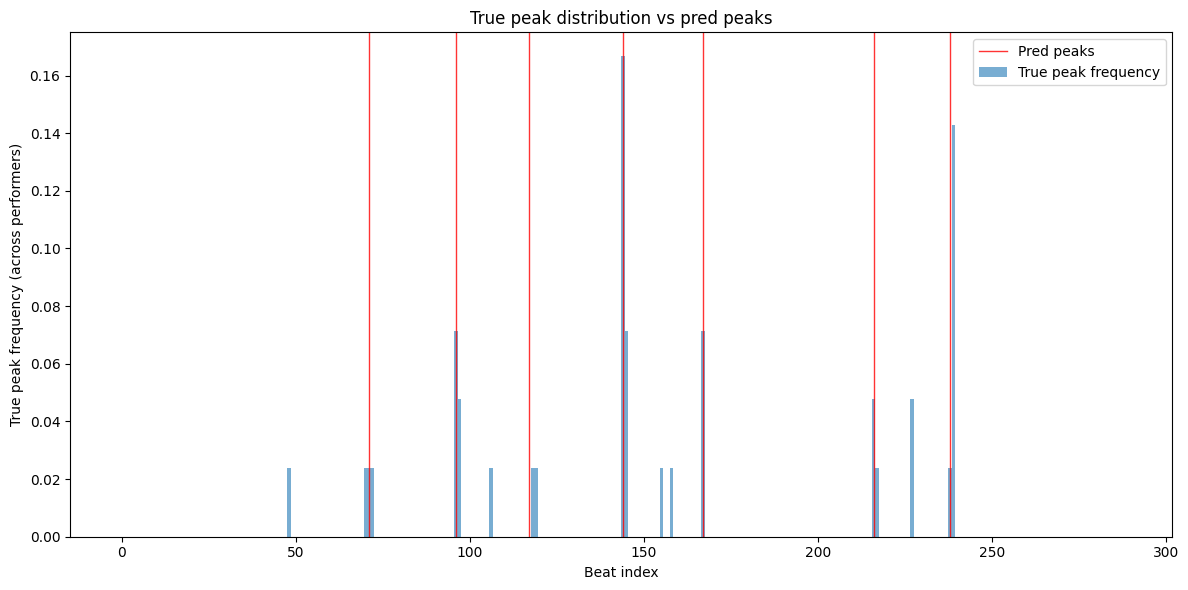

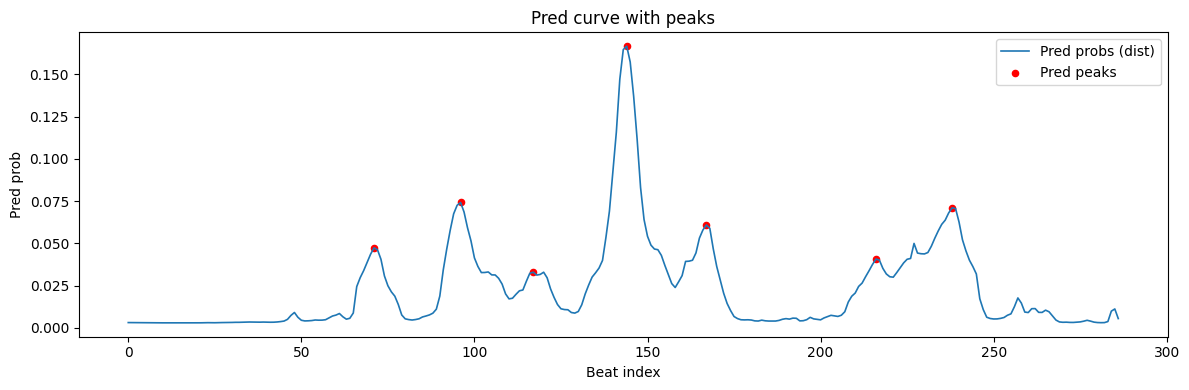

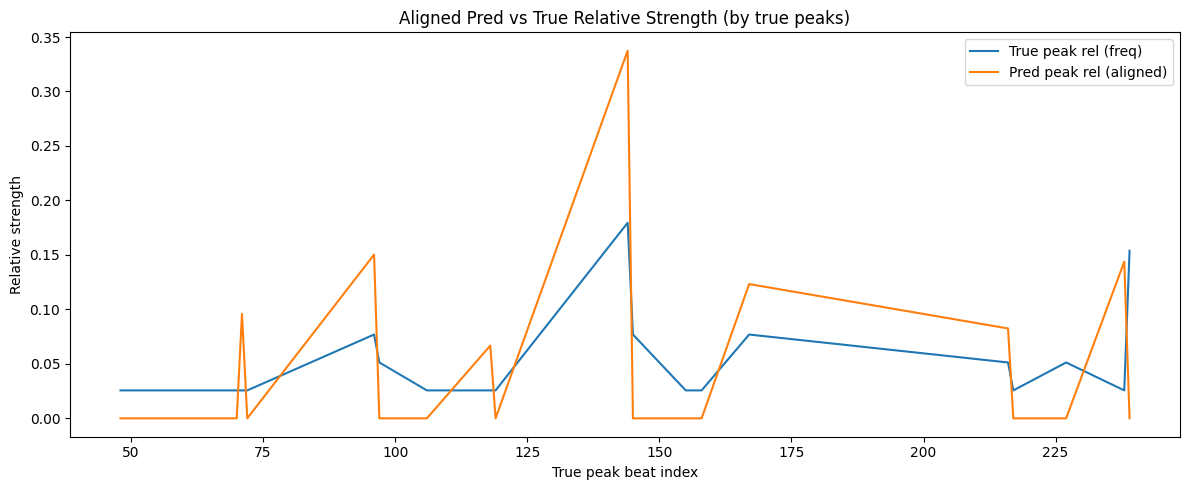

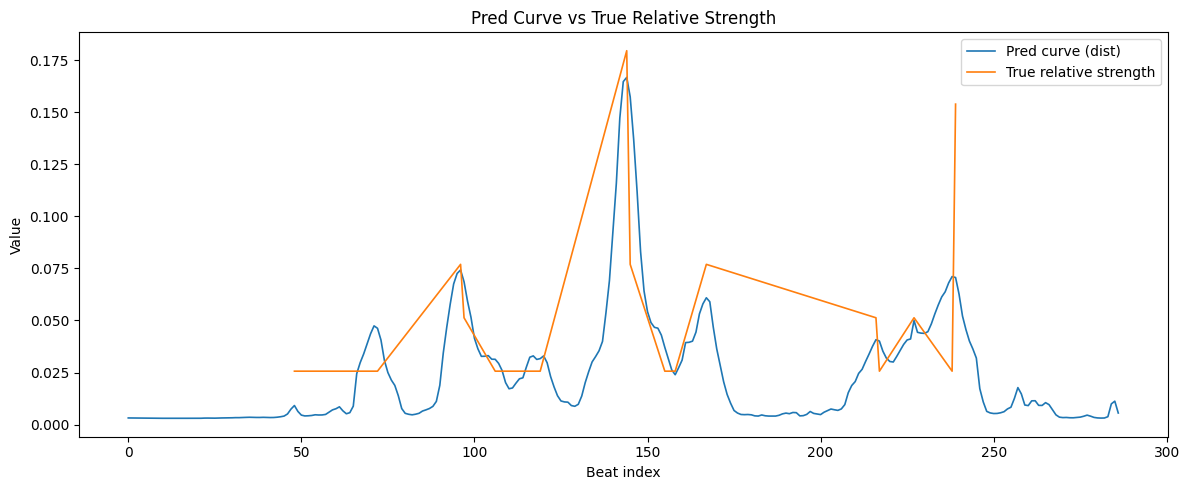

true_avg_peaks: 0.9285714285714286 pred_peak_count: 7


In [19]:
# Cell 3: run
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level6.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_6/beat_mazurka_L6_20260130_141117/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L6.npz",
    output_head="dist",
    pred_height=0.03,
    pred_min_dist=3,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])
